NEA - CDX, CHB, CHS, JPT, KOR

SEA - KHV, MYA, VNK

SWA - BEB, GIH, IN, ITU, NP, PJL, PT, STU

empty blocks in NEA
            rs5768007
SNU-CDX-001
SNU-CDX-002
SNU-CDX-003
SNU-CDX-004
SNU-CDX-005
SNU-CDX-006
SNU-CDX-007
SNU-CDX-008
SNU-CDX-009

1. Why frequencies of base pairs is not continuous?
2. How we should deal with the 'distance' between genotypes?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'

In [2]:
df_NEA = pd.read_csv('../input/서울의대법의학교실_Ancestry SNP Panel Genotype raw data_2022_NEA.csv').dropna(how='any')
df_SEA = pd.read_csv('../input/서울의대법의학교실_Ancestry SNP Panel Genotype raw data_2022_SEA.csv').dropna(how='any')
df_SWA = pd.read_csv('../input/서울의대법의학교실_Ancestry SNP Panel Genotype raw data_2022_SWA.csv').dropna(how='any')
df = pd.concat([df_NEA, df_SEA, df_SWA], axis=0, ignore_index=True).dropna()

In [3]:
region = pd.Series(np.concatenate([
    np.full((df_NEA.shape[0], ), 'NEA'), 
    np.full((df_SEA.shape[0], ), 'SEA'),
    np.full((df_SWA.shape[0], ), 'SWA')
], axis=0))
popl = df['SNU-ID'].str.split('-').apply(lambda x:x[1])

In [4]:
region.value_counts().sort_index()

NEA    646
SEA    498
SWA    391
dtype: int64

In [5]:
popl.value_counts().sort_index()

BEB     18
CHB    100
CHS     99
GIH      5
IN      51
ITU      9
JPT    101
KHV    100
KOR    346
MYA    199
NP     148
PJL     62
PT      89
STU      9
VNK    199
Name: SNU-ID, dtype: int64

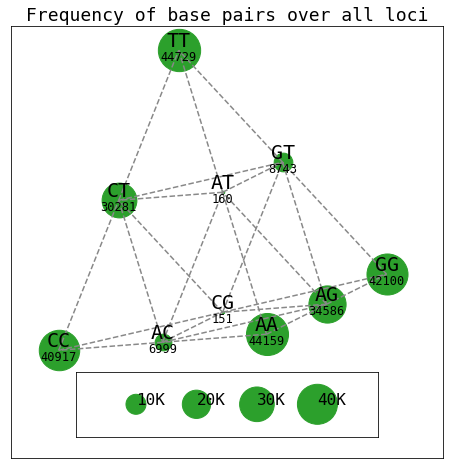

In [6]:
import itertools
bases = 'ACGT'
verts = np.array([[1., 1., 1.], [1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])
azim = 30; lat = 60
azim, lat = azim*(np.pi/180), lat*(np.pi/180)
radial = np.array([np.cos(lat)*np.cos(azim), np.cos(lat)*np.sin(azim), np.sin(lat)])
vertical = np.cross(radial, np.cross([0, 0, 1], radial))
vertical = vertical / np.linalg.norm(vertical)
horizontal = np.cross(vertical, radial)
verts = verts @ np.stack([horizontal, vertical]).T

fig = plt.figure(figsize=(10, 10))
ax = plt.axes([0.2, 0.2, 0.6, 0.6])
# fig, ax = plt.subplots(figsize=(10, 10))
for i, j in itertools.combinations_with_replacement(range(4), 2):
    vert_i, vert_j = verts[i], verts[j]
    vert = (vert_i + vert_j) / 2
    pair = f'{bases[i]}{bases[j]}'
    val = (df.iloc[:, 1:] == pair).sum().sum()
    ax.scatter(*vert.reshape(-1, 1), s=val*4e-2, c='C2', zorder=0)
    ax.text(*vert, pair, fontsize=20, ha='center', va='bottom', zorder=100)
    ax.text(*vert, val, fontsize=12, ha='center', va='top', zorder=100)
    for k, l in itertools.combinations_with_replacement(range(4), 2):
        vert_other = (verts[k] + verts[l]) / 2
        if (i < k and j == l) or (i == k and j < l) or (i == l and j < k) or (i < l and j == k):
            ax.plot(*np.stack([vert, vert_other]).T, c='#888888', linestyle='--')
ax.set_xlim(-0.7, 1.1); ax.set_ylim(-1.2, 0.6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Frequency of base pairs over all loci', fontsize=18)

ax_sub = ax.inset_axes([0.15, 0.05, 0.7, 0.15])
ax_sub.set_xticks([]); ax_sub.set_yticks([])
ax_sub.scatter(np.arange(0.2, 1, 0.2), [0.5]*4, s=np.arange(1, 5, 1)*1e4*4e-2, c='C2', transform=ax_sub.transAxes)
for i in range(4):
    ax_sub.text(0.2*(i+1), 0.5, f'{i+1}0K', fontsize=16, transform=ax_sub.transAxes)
plt.show(); plt.close()

In [55]:
df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df.iloc[:, 1:].iteritems():
        df_ch[f'{gene}_{ch}'] = col.str.count(ch)
    df_ch = pd.DataFrame(df_ch)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)
# df_chs = df_chs.loc[:, df_chs.nunique() > 1]

In [80]:
from gtda.mapper import CubicalCover, Projection, Eccentricity, make_mapper_pipeline, plot_static_mapper_graph
from sklearn.cluster import DBSCAN

class DistFrom():
    def __init__(self, bases):
        self.bases = bases
    
    def __call__(self, X):
        return np.stack([np.linalg.norm(X - base, ord=1) for base in self.bases]).T

class BaseCount():
    def __init__(self, choices=None):
        if choices is None:
            choices = [0, 1, 2, 3]
        self.choices = choices

    def __call__(self, X):
        return np.stack([np.sum(X[..., i::4], axis=-1) for i in range(4)]).T[..., self.choices]




In [122]:
from sklearn.preprocessing import LabelEncoder

pipe = make_mapper_pipeline(
    filter_func=BaseCount(choices=[0, 1, 2, 3]),
    cover=CubicalCover(n_intervals=5, overlap_frac=0.111),
    clusterer=DBSCAN(
        metric='manhattan'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    df_chs.values,
    color_data=LabelEncoder().fit_transform(region)
)
fig.show()

In [105]:
pipe = make_mapper_pipeline(
    filter_func=DistFrom(df_chs.values[[0, 500, 1000]]),
    cover=CubicalCover(n_intervals=8, overlap_frac=0.12),
    clusterer=DBSCAN(
        metric='manhattan'
    ),
)
fig = plot_static_mapper_graph(
    pipe, 
    df_chs.values,
    color_data=LabelEncoder().fit_transform(region)
)
fig.show()

In [35]:
from umap import UMAP
reducer = UMAP(
    n_components=2, 
    metric='manhattan',
    random_state=42
)
pts = reducer.fit_transform(df_chs)

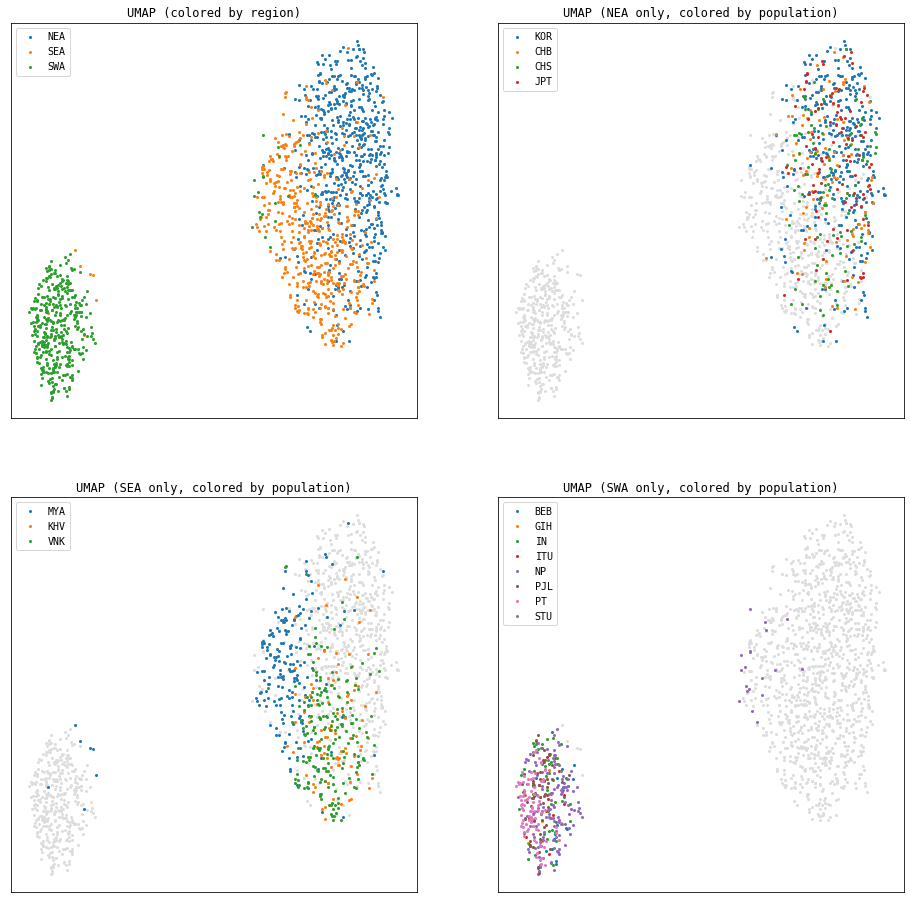

In [36]:
s = 4.

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

ax = axs[0, 0]
for i, reg in enumerate(region.unique()):
    ax.scatter(*pts[region == reg].T, color=f'C{i}', s=s, label=reg)  
ax.set_title('UMAP (colored by region)')

ax = axs[0, 1]
ax.scatter(*pts[region != 'NEA'].T, color='#dddddd', s=s)
for i, pop in enumerate(popl[region == 'NEA'].unique()):
    ax.scatter(*pts[popl == pop].T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (NEA only, colored by population)')

ax = axs[1, 0]
ax.scatter(*pts[region != 'SEA'].T, color='#dddddd', s=s)
for i, pop in enumerate(popl[region == 'SEA'].unique()):
    ax.scatter(*pts[popl == pop].T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (SEA only, colored by population)')

ax = axs[1, 1]
ax.scatter(*pts[region != 'SWA'].T, color='#dddddd', s=s)
for i, pop in enumerate(popl[region == 'SWA'].unique()):
    ax.scatter(*pts[popl == pop].T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (SWA only, colored by population)')

for ax in axs.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend()
plt.show(); plt.close()

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(region)
X_train, X_test, y_train, y_test = train_test_split(df_chs.values, y, test_size=0.2, stratify=y, random_state=42)


clf = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
clf.fit(X_train, y_train)
print(np.mean(clf.predict(X_train) == y_train))
print(np.mean(clf.predict(X_test) == y_test))

0.8379478827361564
0.8110749185667753


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning:

Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.

c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning:

Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. 